# G4. Fairness Mitigation

**Authors:** Ivo Rambaldi and Tommaso Petrelli

**Course:** Ethics in Artificial Intelligence, University of Bologna, a.y. 2025-2026

## What this notebook does

G3 measured how much fairness is lost when the training data is synthetic. This notebook asks
whether that loss can be repaired by the standard mitigation techniques, and whether repair works
as well on a synthetic training set as on a real one.

The second half is what matters for the argument. A practitioner who adopts synthetic data for
privacy reasons and then applies a fairness technique to the result is assuming the technique
behaves the same way.

## The two techniques

- **Equalized odds**, post processing. Fairlearn's `ThresholdOptimizer` picks a separate decision
  threshold per group after the classifier is trained, so that true and false positive rates
  match.
- **Prejudice remover**, in processing. The aif360 implementation of Kamishima et al. 2012, a
  regularised model whose loss penalises dependence between the prediction and the protected
  attribute.

Both take a single protected attribute, so mitigation targets one circumstance at a time and the
grid is every circumstance by every training set by every technique. The unmitigated numbers are
loaded from what G3 saved rather than recomputed, so the before and after comparison uses one
baseline.

Task: the excellence task, the top quarter of the score.
`G4_Fairness_Mitigation_LowPerf.ipynb` runs the identical grid on the underperformance task, and
only the setup cell below differs.

## 1. Setup

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np
import pandas as pd

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

warnings.filterwarnings("ignore")

from src.utils import check_prerequisites, get_logger, load_config, notebook_dirs, select_task

logger = get_logger("G4")
check_prerequisites()

# This is the only cell that differs between this notebook and its twin.
TASK = "high_perf"

cfg = select_task(load_config(PROJECT_ROOT / "config" / "config.yaml"), TASK)
RESULTS_DIR, FIGURES_DIR = notebook_dirs(cfg, f"g4/{TASK}")
G3_RESULTS_DIR = cfg["paths"]["results_dir"] / "g3" / TASK

TARGET = cfg["dataset"]["target_column"]
METHODS = cfg["generation"]["datasets"]
CLASSIFIERS = list(cfg["experiments"]["classifiers"])
BASELINE = cfg["experiments"]["baseline_label"]
TECHNIQUES = cfg["mitigation"]["methods"]

print(f"task       : {TASK}, predicting {TARGET}")
print(f"techniques : {TECHNIQUES}")
print(f"reading G3 : {G3_RESULTS_DIR}")

Prerequisites: 16 satisfied, 0 missing, 0 mismatched.
task       : high_perf, predicting target_high_perf
techniques : ['equalized_odds', 'prejudice_remover']
reading G3 : C:\Users\tomma\Desktop\petrellirambaldi2526\results\g3\high_perf


## 2. Data and the unmitigated baseline

The data is prepared exactly as in G3, using the same feature set and the same encoders fitted on
the real training set. The unmitigated results are read from disk rather than recomputed.

In [2]:
from src.data.loader import load_real_data, load_synthetic_dataset
from src.data.preprocessing import get_feature_columns
from src.data.preprocessor import DataSplit, apply_feature_encoders, fit_feature_encoders

real_train, real_test = load_real_data(cfg)
synthetic_raw = {m: load_synthetic_dataset(cfg, m) for m in METHODS}

FEATURES = get_feature_columns(real_train, cfg)
PROTECTED = [c for c in cfg["dataset"]["protected_attributes"] if c in real_train.columns]

encoder, scaler, cat_cols, num_cols = fit_feature_encoders(real_train[FEATURES])


def encode(df):
    aligned = pd.DataFrame({c: df[c] for c in FEATURES}, index=df.index)
    return apply_feature_encoders(aligned, encoder, scaler, cat_cols, num_cols)


split = DataSplit(
    X_train=encode(real_train),
    X_test=encode(real_test),
    y_train=real_train[TARGET].astype(int),
    y_test=real_test[TARGET].astype(int),
    protected_train=real_train[PROTECTED],
    protected_test=real_test[PROTECTED],
    feature_names=FEATURES,
    target_name=TARGET,
    protected_attrs=PROTECTED,
)

unmitigated = pd.read_csv(G3_RESULTS_DIR / "metrics_matrix.csv")
print(f"Loaded the unmitigated grid from G3: {unmitigated.shape[0]} rows")

2026-08-01 22:03:19 | INFO     | src.data.loader | Loading real splits from C:\Users\tomma\Desktop\petrellirambaldi2526\Data\train.csv and C:\Users\tomma\Desktop\petrellirambaldi2526\Data\test.csv


2026-08-01 22:03:19 | INFO     | src.data.loader | Loading synthetic data [ctgan] from C:\Users\tomma\Desktop\petrellirambaldi2526\results\synthetic\ctgan\synthetic_ctgan.csv


2026-08-01 22:03:19 | INFO     | src.data.loader | Loading synthetic data [tvae] from C:\Users\tomma\Desktop\petrellirambaldi2526\results\synthetic\tvae\synthetic_tvae.csv


2026-08-01 22:03:20 | INFO     | src.data.loader | Loading synthetic data [gaussian_copula] from C:\Users\tomma\Desktop\petrellirambaldi2526\results\synthetic\copula\synthetic_copula.csv


2026-08-01 22:03:20 | INFO     | src.data.loader | Loading synthetic data [smote] from C:\Users\tomma\Desktop\petrellirambaldi2526\results\synthetic\smote\synthetic_smote.csv


2026-08-01 22:03:20 | INFO     | src.data.preprocessing | Feature set: 38 columns


Loaded the unmitigated grid from G3: 15 rows


In [3]:
# Each training source carries its own protected attribute values. A synthetic set has a
# different number of rows from the real one, so the real columns cannot be reused for it.
train_sources = {BASELINE: (split.X_train, split.y_train, real_train[PROTECTED])}
for method, df in synthetic_raw.items():
    train_sources[method] = (encode(df), df[TARGET].astype(int), df[PROTECTED])

n_fits = len(PROTECTED) * len(train_sources) * (len(CLASSIFIERS) + 1)
print(f"{len(PROTECTED)} circumstances by {len(train_sources)} training sets "
      f"by {len(CLASSIFIERS)} classifiers plus one prejudice remover: {n_fits} fits")

13 circumstances by 5 training sets by 3 classifiers plus one prejudice remover: 260 fits


## 3. Running the mitigation grid

Two limits on what the grid can do.

**Unanswered circumstances.** Both libraries need a group label for every row. Only the rows where
the group is known are used to fit, so the constraint is never learned from invented membership.
Rows with an unanswered circumstance still receive a prediction, using the larger group for
thresholding, and the metric is computed only where the group is known, as in G3.

**Combinations that cannot run.** Both libraries also need two groups present, each carrying both
labels. A synthetic training set need not satisfy that, so a refusal is recorded and counted
rather than allowed to stop the grid.

In [4]:
from src.evaluation.evaluator import MitigatedEvaluator

mitigated_evaluator = MitigatedEvaluator(split, cfg)
rows = []

for attribute in PROTECTED:
    for method, (X_train, y_train, protected_train) in train_sources.items():
        attr_train = protected_train[attribute]

        for technique in TECHNIQUES:
            classifiers = CLASSIFIERS if technique == "equalized_odds" else [None]
            for classifier in classifiers:
                try:
                    rows.append(mitigated_evaluator.evaluate(
                        X_train, y_train,
                        technique=technique,
                        target_attr=attribute,
                        method_name=method,
                        attr_train=attr_train,
                        classifier_name=classifier,
                    ))
                except ValueError as error:
                    logger.warning(f"  skipped {technique} {attribute} {method}: {error}")
                    rows.append({
                        "technique": technique, "target_attr": attribute, "method": method,
                        "classifier": classifier or technique,
                        "balanced_accuracy": float("nan"), "error": str(error),
                    })

mitigation = pd.DataFrame(rows)
failed = int(mitigation["error"].notna().sum()) if "error" in mitigation.columns else 0
print(f"\n{len(mitigation)} fits, {failed} refused by the library")

2026-08-01 22:03:22 | INFO     | src.evaluation.evaluator |   [equalized_odds | s_gender | real | logistic_regression] BA=0.6232 mean_dpd=0.3139


2026-08-01 22:03:25 | INFO     | src.evaluation.evaluator |   [equalized_odds | s_gender | real | xgboost] BA=0.6553 mean_dpd=0.3228


2026-08-01 22:03:41 | INFO     | src.evaluation.evaluator |   [equalized_odds | s_gender | real | mlp] BA=0.6403 mean_dpd=0.2381


pip install 'aif360[AdversarialDebiasing]'


pip install 'aif360[AdversarialDebiasing]'


...

2026-08-01 23:17:50 | INFO     | src.evaluation.evaluator |   [equalized_odds | f_ESCS | smote | logistic_regression] BA=0.5264 mean_dpd=0.0444


2026-08-01 23:17:53 | INFO     | src.evaluation.evaluator |   [equalized_odds | f_ESCS | smote | xgboost] BA=0.5213 mean_dpd=0.0318


2026-08-01 23:18:14 | INFO     | src.evaluation.evaluator |   [equalized_odds | f_ESCS | smote | mlp] BA=0.5589 mean_dpd=0.0765


2026-08-01 23:19:20 | INFO     | src.evaluation.evaluator |   [prejudice_remover | f_ESCS | smote | prejudice_remover] BA=0.5597 mean_dpd=0.1248



260 fits, 0 refused by the library


In [5]:
from src.data.persistence import save_csv

save_csv(mitigation, RESULTS_DIR / "mitigation_results.csv")

2026-08-01 23:19:20 | INFO     | src.data.persistence | Saved 260 rows to C:\Users\tomma\Desktop\petrellirambaldi2526\results\g4\high_perf\mitigation_results.csv


## 4. Effect on the targeted circumstance

The averages across all circumstances answer a different question from the one the techniques
were set. Each mitigated run targeted one attribute, so the fair test is whether that attribute's
own DPD, EOD and DI improved against the matching unmitigated run.

Improvement is signed so that positive always means fairer: for DPD and EOD, the drop, and for
DI, the rise.

In [6]:
def unmitigated_reference(method, classifier, attribute):
    """The matching row from G3. Prejudice remover has no classifier, so average across them."""
    subset = unmitigated[unmitigated["method"] == method]
    if classifier in CLASSIFIERS:
        subset = subset[subset["classifier"] == classifier]
    return {m: subset[f"{attribute}_{m}"].mean() for m in ("dpd", "eod", "di")}


comparisons = []
for _, row in mitigation.iterrows():
    attribute = row["target_attr"]
    before = unmitigated_reference(row["method"], row["classifier"], attribute)

    entry = {
        "technique": row["technique"], "target_attr": attribute, "method": row["method"],
        "classifier": row["classifier"], "balanced_accuracy": row["balanced_accuracy"],
    }
    for metric in ("dpd", "eod", "di"):
        after = row.get(f"{attribute}_{metric}", float("nan"))
        entry[f"{metric}_before"] = before[metric]
        entry[f"{metric}_after"] = after
        entry[f"{metric}_improvement"] = (
            after - before[metric] if metric == "di" else before[metric] - after
        )
    comparisons.append(entry)

comparison = pd.DataFrame(comparisons)
save_csv(comparison, RESULTS_DIR / "mitigation_comparison.csv")
print(f"{len(comparison)} before and after pairs")

2026-08-01 23:19:20 | INFO     | src.data.persistence | Saved 260 rows to C:\Users\tomma\Desktop\petrellirambaldi2526\results\g4\high_perf\mitigation_comparison.csv


260 before and after pairs


In [7]:
by_technique = (
    comparison.groupby("technique")[
        ["balanced_accuracy", "dpd_improvement", "eod_improvement", "di_improvement"]
    ].mean().round(4)
)
print("Mean effect of each technique, positive improvement means fairer:")
print(by_technique.to_string())

degenerate = mitigation.groupby("technique")["degenerate_predictions"].sum()
print(f"\nMitigated fits that collapsed to a single predicted class: {degenerate.to_dict()}")

Mean effect of each technique, positive improvement means fairer:
                   balanced_accuracy  dpd_improvement  eod_improvement  di_improvement
technique                                                                             
equalized_odds                0.5631           0.1312           0.1453          0.3165
prejudice_remover             0.5443           0.1037           0.0948         -0.0774

Mitigated fits that collapsed to a single predicted class: {'equalized_odds': 0, 'prejudice_remover': 10}


**Observation.** Read the improvement columns next to the balanced accuracy column. Both
techniques reduce the gap on the attribute they target; the question is what they charge for it,
and whether the DI improvement moves with the DPD and EOD ones. A technique that equalises rates
by pushing both groups towards never predicting the positive class shows a healthy DPD
improvement and a poor accuracy.

## 5. Mitigation on real against synthetic training data

This is the question the notebook exists to answer. If the two sources are close, a practitioner
can substitute synthetic data and still rely on their fairness tooling.

The improvement alone cannot settle it, because the two sources do not arrive with the same gap to
close. The table reports three quantities per technique: the gap before, the gap left after, and
the share closed. The first is the confound, the second is what the student is left with, and the
third is the like for like comparison.

In [8]:
comparison["source"] = np.where(comparison["method"] == BASELINE, "real", "synthetic")

by_source = (
    comparison.groupby(["technique", "source"])[
        ["dpd_before", "dpd_after", "dpd_improvement", "eod_improvement",
         "di_improvement", "balanced_accuracy"]
    ].mean()
)
by_source["share_closed"] = by_source["dpd_improvement"] / by_source["dpd_before"]

print("Mitigation effectiveness, real against synthetic training data:")
print(by_source.round(4).to_string())
save_csv(by_source.reset_index(), RESULTS_DIR / "mitigation_by_source.csv")

Mitigation effectiveness, real against synthetic training data:
                             dpd_before  dpd_after  dpd_improvement  eod_improvement  di_improvement  balanced_accuracy  share_closed
technique         source                                                                                                             
equalized_odds    real           0.2526     0.0347           0.2180           0.2384          0.4454             0.6182        0.8628
                  synthetic      0.2196     0.1101           0.1095           0.1221          0.2813             0.5494        0.4988
prejudice_remover real           0.2526     0.0554           0.1973           0.1781         -0.1631             0.5324        0.7809
                  synthetic      0.2196     0.1393           0.0802           0.0740         -0.0509             0.5473        0.3654
2026-08-01 23:19:20 | INFO     | src.data.persistence | Saved 4 rows to C:\Users\tomma\Desktop\petrellirambaldi2526\results\g4\high_

2026-08-01 23:19:26 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g4\high_perf\mitigation_real_vs_synthetic.png


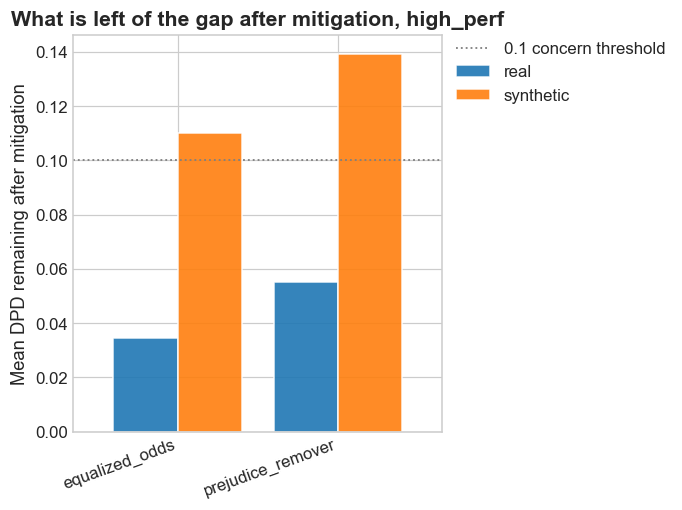

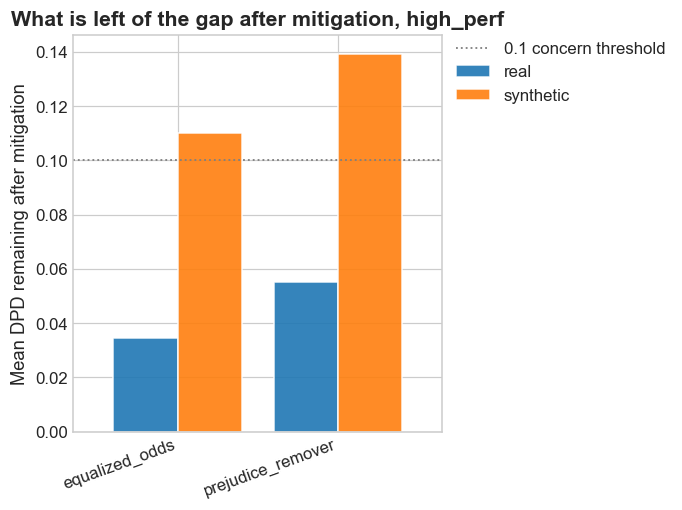

In [9]:
from src.utils.plotting import plot_grouped_bars

pivot = comparison.pivot_table(index="technique", columns="source",
                               values="dpd_after", aggfunc="mean")
plot_grouped_bars(pivot, "Mean DPD remaining after mitigation",
                  f"What is left of the gap after mitigation, {TASK}",
                  FIGURES_DIR, "mitigation_real_vs_synthetic",
                  reference_line=cfg["fairness"]["dpd_threshold"],
                  reference_label="0.1 concern threshold")

**Observation.** Read the three columns together within a technique. If the synthetic side closes
a smaller share of a smaller gap and is left further from parity, all three point the same way
and the shortfall is not an artefact of the starting point. If they disagree, the starting point
is doing the work and the claim has to be weakened accordingly.

The figure plots what is left rather than what was removed, because that is the quantity a
student is subject to. G5 checks whether the pattern holds on both tasks.

### 5.1 Per circumstance

Not every circumstance responds the same way. The ones with the widest starting gap have the most
to gain, and the ones measured on few students are the least reliable.

In [10]:
by_attribute = (
    comparison.groupby(["target_attr", "technique"])["dpd_improvement"]
    .mean().unstack("technique").round(4)
    .sort_values(TECHNIQUES[0], ascending=False)
)
print("Mean DPD improvement per circumstance:")
print(by_attribute.to_string())

Mean DPD improvement per circumstance:
technique                                          equalized_odds  prejudice_remover
target_attr                                                                         
f_mother_education_level                                   0.2194             0.1742
p_public_or_private                                        0.2090             0.1689
f_father_occupation                                        0.2078             0.1286
f_extent_of_books_at_home                                  0.2021             0.1836
f_father_education_level                                   0.2019             0.1294
f_mother_occupation                                        0.1916             0.1376
f_ESCS                                                     0.1743             0.1945
p_percentage_of_teachers_changed_school_last_year          0.1354             0.0810
f_start_schooling_age                                      0.1069             0.0906
s_birth_country           

2026-08-01 23:19:27 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g4\high_perf\mitigation_by_attribute.png


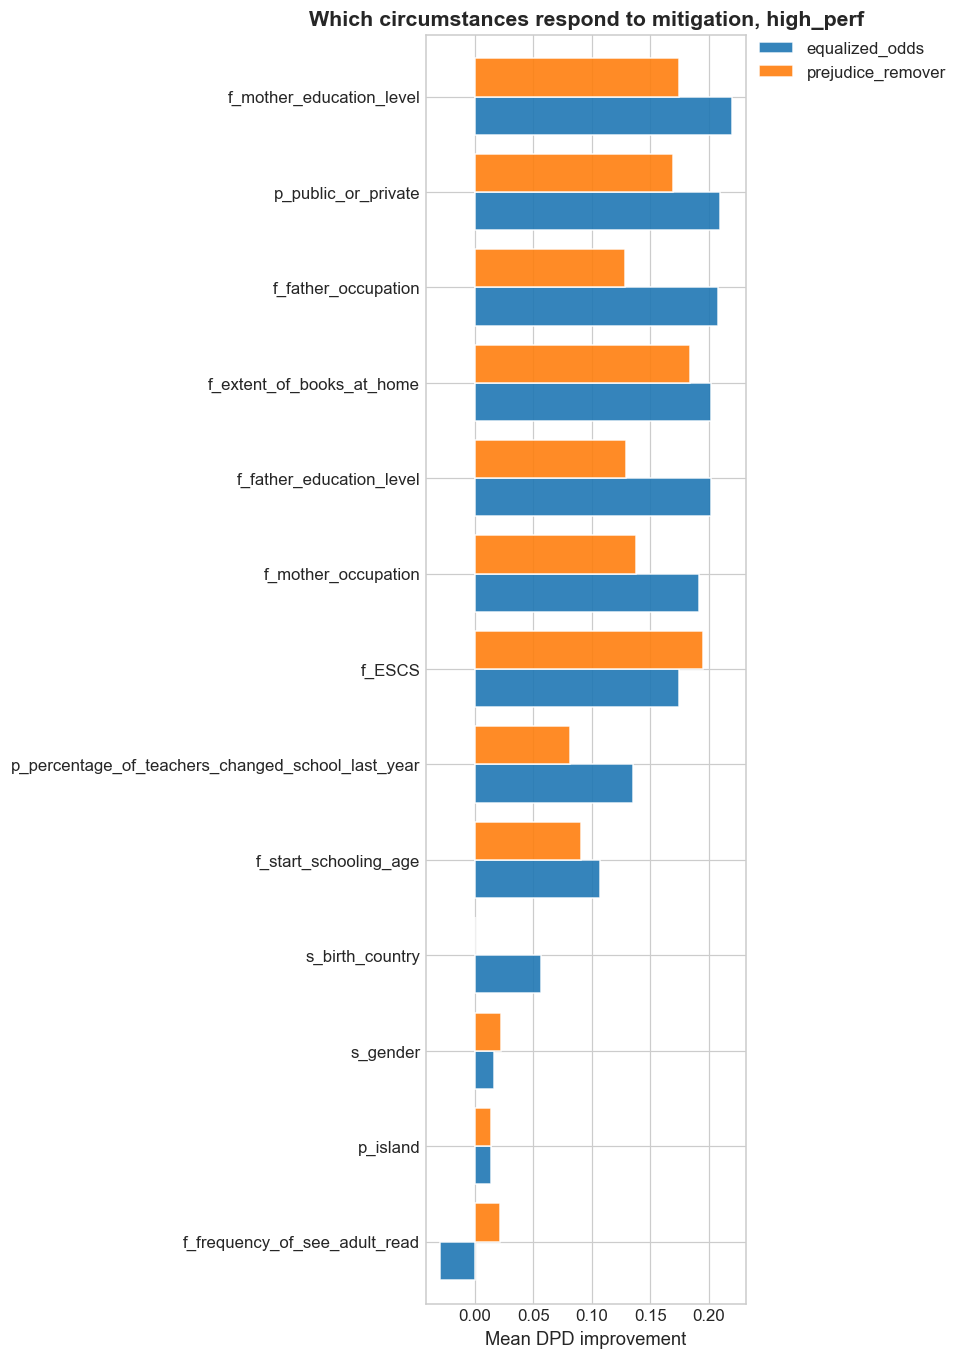

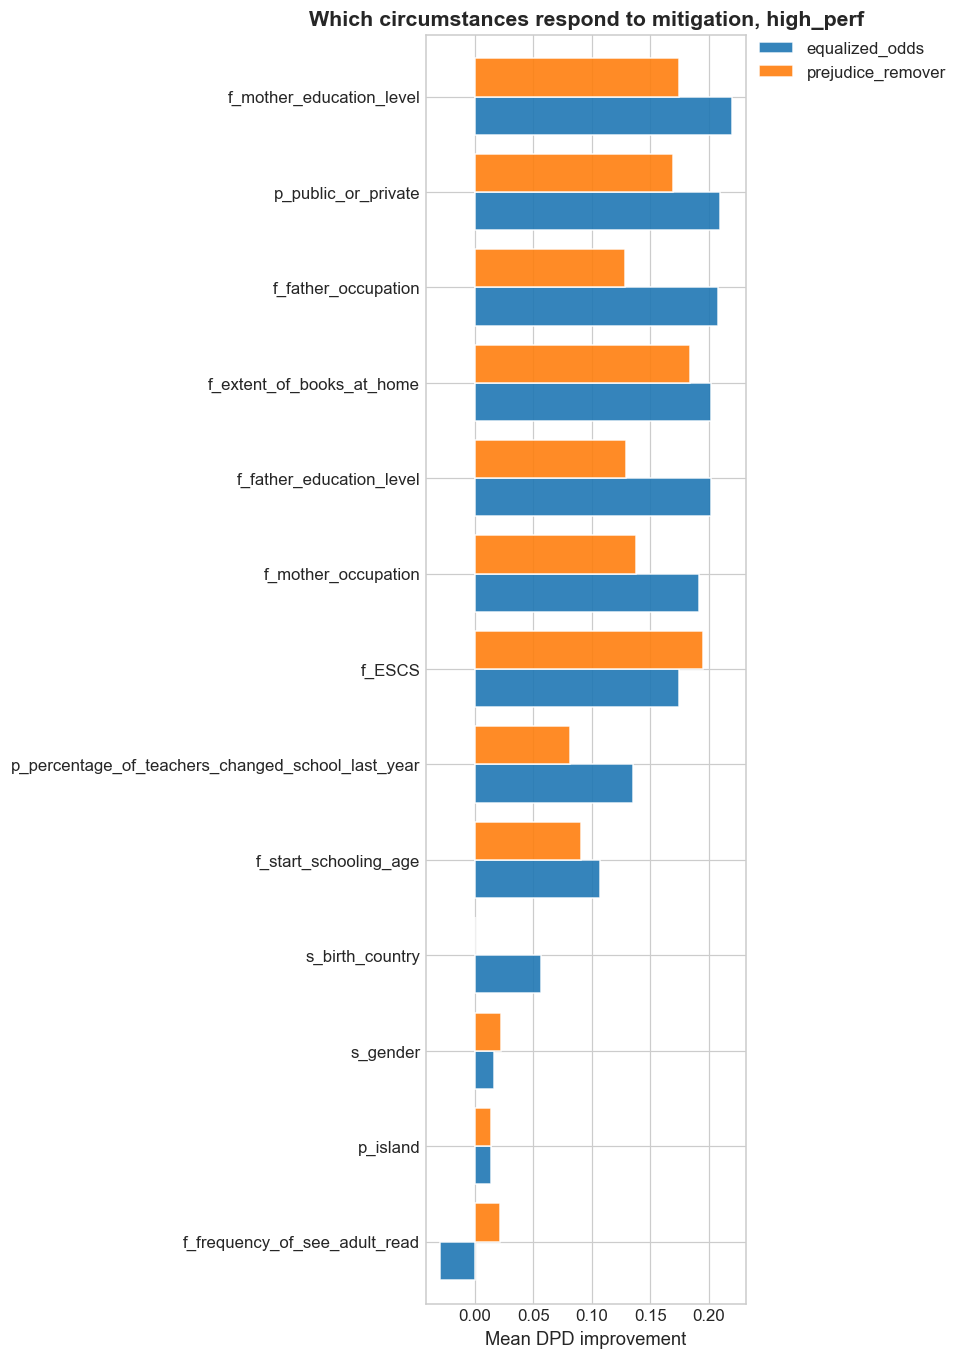

In [11]:
plot_grouped_bars(by_attribute, "Mean DPD improvement",
                  f"Which circumstances respond to mitigation, {TASK}",
                  FIGURES_DIR, "mitigation_by_attribute")

## 6. The cost in accuracy

In [12]:
cost = comparison.groupby(["technique", "source"])["balanced_accuracy"].mean().unstack("source")
unmitigated_reference_ba = (
    unmitigated.assign(source=np.where(unmitigated["method"] == BASELINE, "real", "synthetic"))
    .groupby("source")["balanced_accuracy"].mean()
)
cost.loc["none"] = unmitigated_reference_ba
print("Mean balanced accuracy, before and after mitigation:")
print(cost.round(4).to_string())

Mean balanced accuracy, before and after mitigation:
source               real  synthetic
technique                           
equalized_odds     0.6182     0.5494
prejudice_remover  0.5324     0.5473
none               0.6117     0.5605


**Observation.** The `none` row is the unmitigated starting point from G3. Comparing the technique
rows against it gives the price of the repair, separately for real and for synthetic training
data.

## 7. Final observations

- Both techniques reduce the gap on the circumstance they target, at a cost in accuracy that
  differs between them.
- The comparison that matters is real against synthetic within a technique, and it has to be read
  on the residual gap as well as on the improvement, because the two sources do not start from
  the same gap.
- Fairness measured on a heavily unanswered circumstance rests on the students who answered, and
  mitigation of that circumstance is fitted on the same subset. Both limits are carried into G5.

Saved for G5: `mitigation_results.csv`, `mitigation_comparison.csv` and
`mitigation_by_source.csv`.